
##  GDP per Capita Forecasting – Norway


## ─────────────────────────────────────────────────────────────
###  Data Preparation & Train/Test Split
## ─────────────────────────────────────────────────────────────

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.forecasting.stl import STLForecast

# LOAD & SPLIT DATA

df = pd.read_excel("Dataset.xlsx")
df.columns = ["Year", "Country", "GDP_per_capita"]
df = df.sort_values("Year").reset_index(drop=True)

TEST_SIZE   = 9
train       = df.iloc[:-TEST_SIZE].copy()
test        = df.iloc[-TEST_SIZE:].copy()
y_train     = train["GDP_per_capita"].values
y_test      = test["GDP_per_capita"].values
years_train = train["Year"].values
years_test  = test["Year"].values

fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
print(f"Training : {years_train[0]} – {years_train[-1]}  ({len(y_train)} obs)")
print(f"Testing  : {years_test[0]}  – {years_test[-1]}   ({len(y_test)} obs)")



Training : 1960 – 2015  (56 obs)
Testing  : 2016  – 2024   (9 obs)


## ─────────────────────────────────────────────────────────────
###  Decomposition
## ─────────────────────────────────────────────────────────────

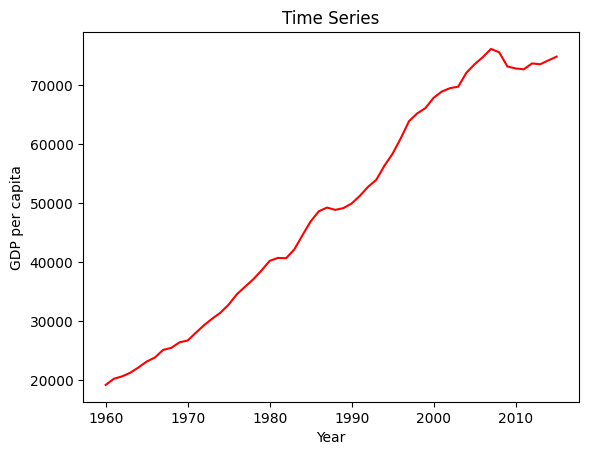

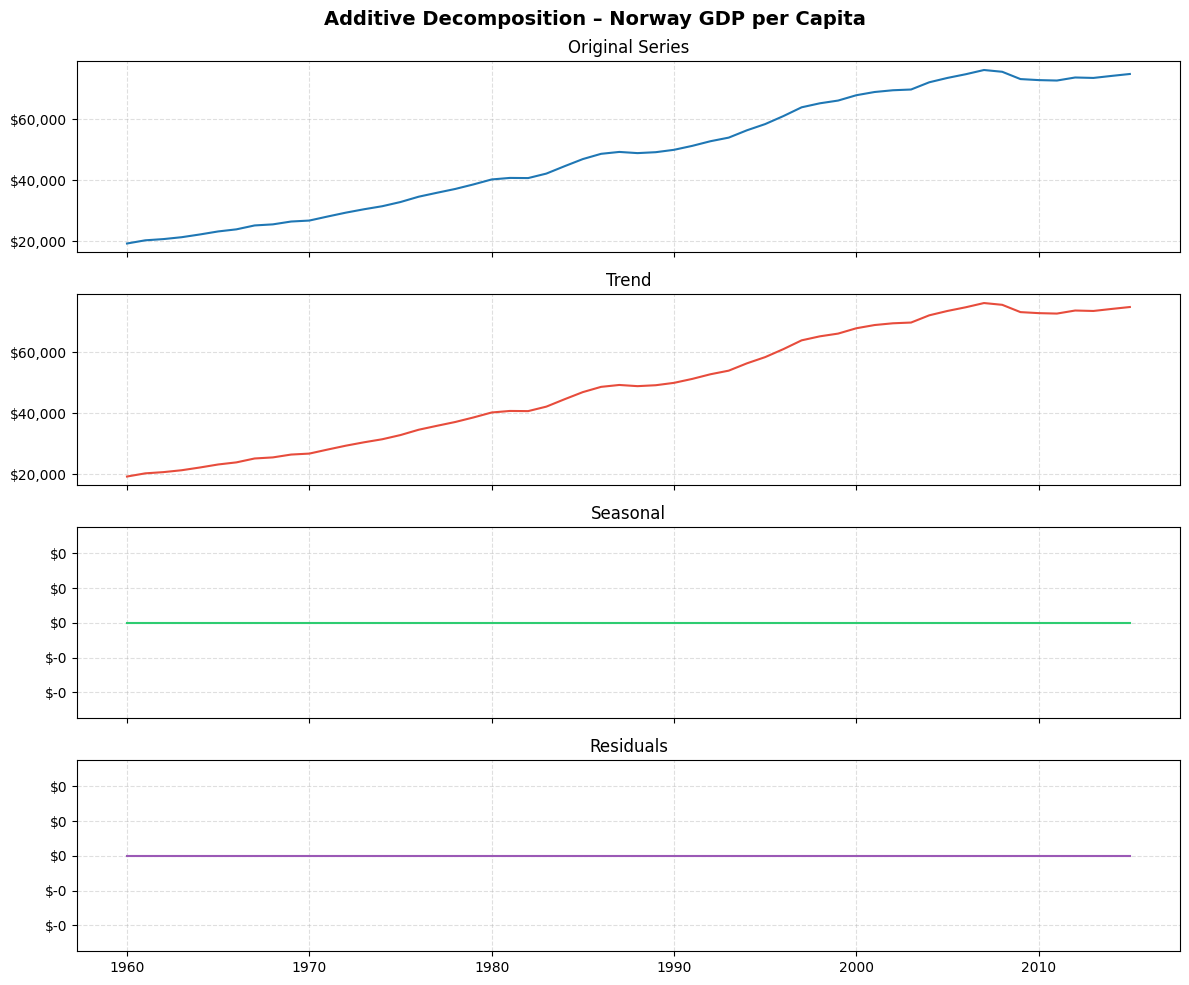

In [14]:
decomp = seasonal_decompose(y_train, model="additive", period=1, extrapolate_trend="freq")

plt.plot(years_train, y_train, color='red')
plt.xlabel('Year')
plt.ylabel('GDP per capita')
plt.title('Time Series')
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(years_train, y_train,            color="#1f77b4"); axes[0].set_title("Original Series")
axes[1].plot(years_train, decomp.trend,       color="#e74c3c"); axes[1].set_title("Trend")
axes[2].plot(years_train, decomp.seasonal,    color="#2ecc71"); axes[2].set_title("Seasonal")
axes[3].plot(years_train, decomp.resid,       color="#9b59b6"); axes[3].set_title("Residuals")
for ax in axes:
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(True, linestyle="--", alpha=0.4)
plt.suptitle("Additive Decomposition – Norway GDP per Capita", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("diag1_decomposition.png", dpi=150)
plt.show()



#### **Confirms there is no seasonality.**

## ─────────────────────────────────────────────────────────────
###  BOX-COX TRANSFORMATION
## ─────────────────────────────────────────────────────────────


── Box-Cox ──
  Best lambda : 0.6773
  (lambda ≈ 0 → log transform;  lambda ≈ 1 → no transform needed)


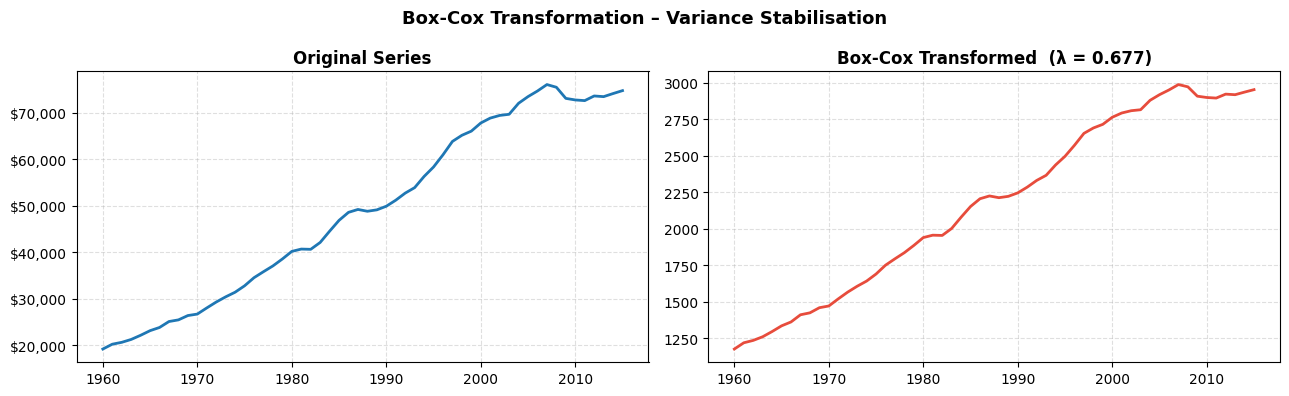

In [15]:

y_transformed, lam = stats.boxcox(y_train)
print(f"\n── Box-Cox ──")
print(f"  Best lambda : {lam:.4f}")
print(f"  (lambda ≈ 0 → log transform;  lambda ≈ 1 → no transform needed)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(years_train, y_train,         color="#1f77b4", linewidth=2)
axes[0].set_title("Original Series",       fontsize=12, fontweight="bold")
axes[0].yaxis.set_major_formatter(fmt)
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].plot(years_train, y_transformed,   color="#e74c3c", linewidth=2)
axes[1].set_title(f"Box-Cox Transformed  (λ = {lam:.3f})", fontsize=12, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Box-Cox Transformation – Variance Stabilisation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("diag2_boxcox.png", dpi=150)
plt.show()
y_model = y_transformed  




── ADF Test : Box-Cox Transformed (level) ──
  ADF Statistic : -1.2608
  p-value       : 0.6469
  Critical 5%   : -2.9168
  → Non-stationary. Differencing required.

── ADF Test : First Difference ──
  ADF Statistic : -3.8726
  p-value       : 0.0022
  Critical 5%   : -2.9168
  → Stationary. No differencing needed.

── ADF Test : Second Difference ──
  ADF Statistic : -6.2950
  p-value       : 0.0000
  Critical 5%   : -2.9190
  → Stationary. No differencing needed.

  → Using d = 1 in ARIMA


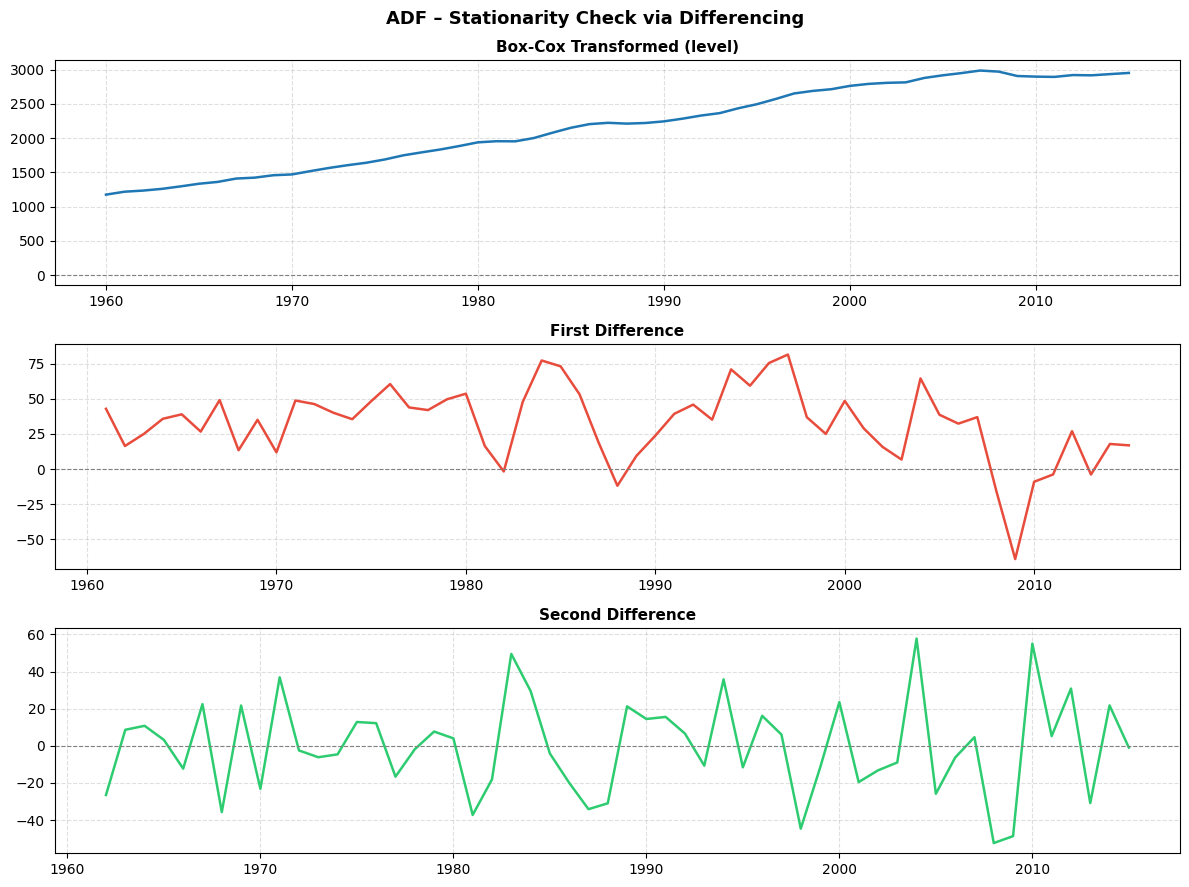

In [16]:

# ADF TEST  (Augmented Dickey-Fuller)
# To test whether the series is stationary.

def run_adf(series, label):
    result = adfuller(series)
    print(f"\n── ADF Test : {label} ──")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical 5%   : {result[4]['5%']:.4f}")
    if result[1] > 0.05:
        print("  → Non-stationary. Differencing required.")
    else:
        print("  → Stationary. No differencing needed.")
    return result[1]

p_original = run_adf(y_model, "Box-Cox Transformed (level)")

# First differencing
y_diff1 = np.diff(y_model)
p_diff1 = run_adf(y_diff1, "First Difference")

# Second differencing 
y_diff2 = np.diff(y_diff1)
p_diff2 = run_adf(y_diff2, "Second Difference")

if   p_original <= 0.05: d = 0
elif p_diff1    <= 0.05: d = 1
else:                    d = 2

print(f"\n  → Using d = {d} in ARIMA")

# Plotting original and differenced series
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)
axes[0].plot(years_train,          y_model,  color="#1f77b4", linewidth=1.8)
axes[0].set_title("Box-Cox Transformed (level)",  fontsize=11, fontweight="bold")
axes[1].plot(years_train[1:],      y_diff1,  color="#e74c3c", linewidth=1.8)
axes[1].set_title("First Difference",             fontsize=11, fontweight="bold")
axes[2].plot(years_train[2:],      y_diff2,  color="#2ecc71", linewidth=1.8)
axes[2].set_title("Second Difference",            fontsize=11, fontweight="bold")
for ax in axes:
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.grid(True, linestyle="--", alpha=0.4)
plt.suptitle("ADF – Stationarity Check via Differencing", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("differencing_figure.png", dpi=150)
plt.show()



## ─────────────────────────────────────────────────────────────
###  ACF & PACF PLOTS
## ─────────────────────────────────────────────────────────────

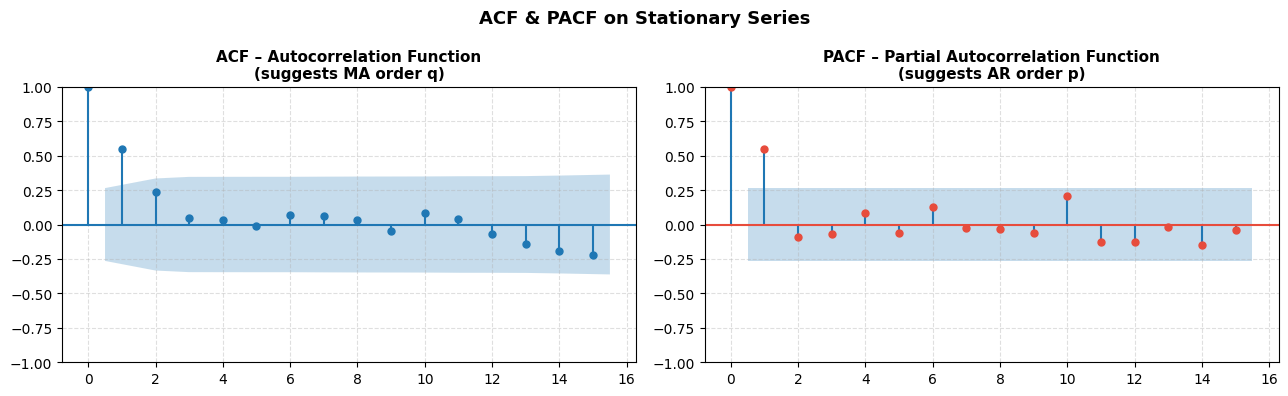

In [17]:

stationary_series = y_diff1 

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(stationary_series,  lags=15, ax=axes[0], color="#1f77b4")
axes[0].set_title("ACF – Autocorrelation Function\n(suggests MA order q)",
                  fontsize=11, fontweight="bold")
plot_pacf(stationary_series, lags=15, ax=axes[1], color="#e74c3c", method="ywm")
axes[1].set_title("PACF – Partial Autocorrelation Function\n(suggests AR order p)",
                  fontsize=11, fontweight="bold")
for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.4)
plt.suptitle("ACF & PACF on Stationary Series", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("diag4_acf_pacf.png", dpi=150)
plt.show()



## ─────────────────────────────────────────────────────────────
### **KPSS Test**
* #### For original series
## ─────────────────────────────────────────────────────────────

In [18]:
from statsmodels.tsa.stattools import kpss


stat, p_value, lags, critical_values = kpss(df["GDP_per_capita"], regression='c')

print("KPSS Statistic:", stat)
print("p-value:", p_value)
print("Lags used:", lags)
print("Critical values:", critical_values)

KPSS Statistic: 1.1669915182026414
p-value: 0.01
Lags used: 5
Critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\Shreevani K\AppData\Local\Temp\ipykernel_4664\4099925510.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, critical_values = kpss(df["GDP_per_capita"], regression='c')


## ─────────────────────────────────────────────────────────────
### **KPSS Test**
* #### For Transformed Series
## ─────────────────────────────────────────────────────────────

In [19]:
diff_series = df["GDP_per_capita"].diff().dropna()

stat, p_value, lags, critical_values = kpss(diff_series, regression='c')

print("KPSS Statistic:", stat)
print("p-value:", p_value)

KPSS Statistic: 0.3020474029496639
p-value: 0.1


C:\Users\Shreevani K\AppData\Local\Temp\ipykernel_4664\230120604.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, critical_values = kpss(diff_series, regression='c')


## ─────────────────────────────────────────────────────────────
###  FORECASTING METHODS
* ### MEAN AND NAIVE FORECASTING

## ─────────────────────────────────────────────────────────────


--- Forecast Accuracy ---
Mean  -> MAE: 28259.52, RMSE: 28308.63
Naive -> MAE: 2469.39, RMSE: 2979.17

── Mean Forecast vs Actual ──
    Year  GDP_per_capita  mean_forecast
56  2016        75017.49       49019.83
57  2017        76247.41       49019.83
58  2018        76373.65       49019.83
59  2019        76712.29       49019.83
60  2020        75287.21       49019.83
61  2021        77812.71       49019.83
62  2022        79620.16       49019.83
63  2023        78775.75       49019.83
64  2024        79667.53       49019.83

── Naive Forecast vs Actual ──
    Year  GDP_per_capita  naive_forecast
56  2016        75017.49        74809.97
57  2017        76247.41        74809.97
58  2018        76373.65        74809.97
59  2019        76712.29        74809.97
60  2020        75287.21        74809.97
61  2021        77812.71        74809.97
62  2022        79620.16        74809.97
63  2023        78775.75        74809.97
64  2024        79667.53        74809.97


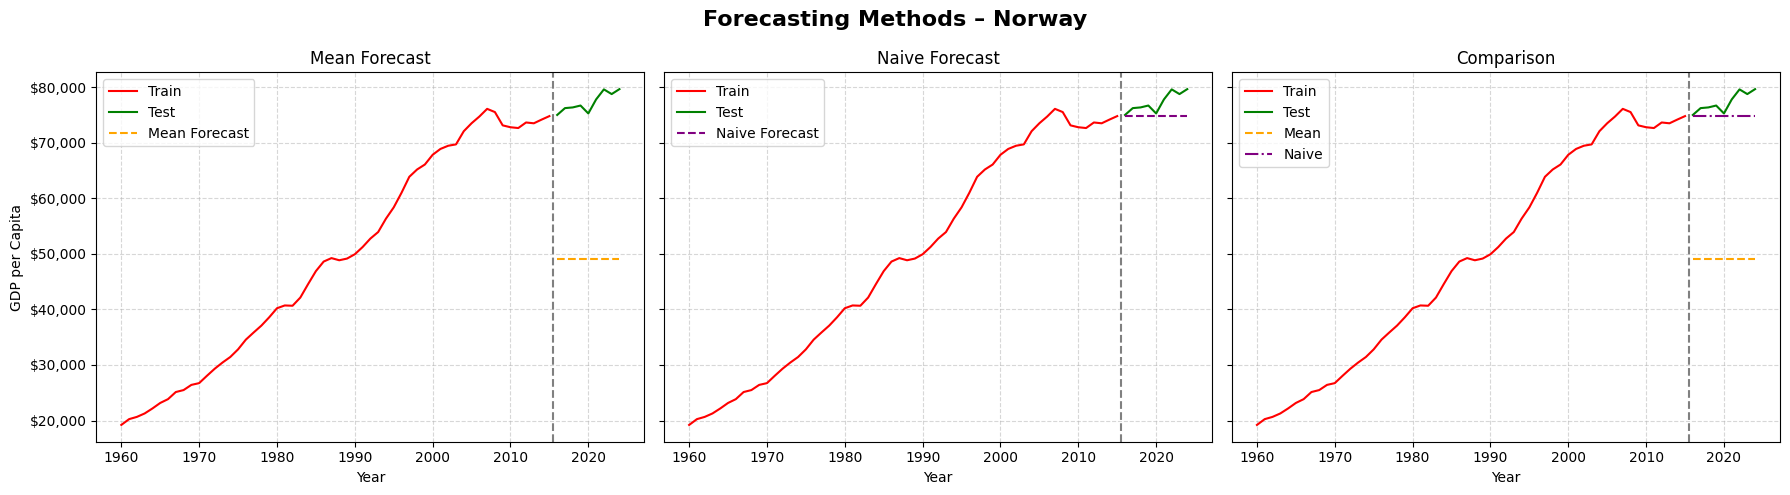

In [20]:
# 1. MEAN FORECAST
mean_value = train["GDP_per_capita"].mean()
test["mean_forecast"] = mean_value


# 2. NAIVE FORECAST
last_value = train["GDP_per_capita"].iloc[-1]
test["naive_forecast"] = last_value


# ERROR METRICS
mae_mean = mean_absolute_error(test["GDP_per_capita"], test["mean_forecast"])
rmse_mean = np.sqrt(mean_squared_error(test["GDP_per_capita"], test["mean_forecast"]))

mae_naive = mean_absolute_error(test["GDP_per_capita"], test["naive_forecast"])
rmse_naive = np.sqrt(mean_squared_error(test["GDP_per_capita"], test["naive_forecast"]))

print("\n--- Forecast Accuracy ---")
print(f"Mean  -> MAE: {mae_mean:.2f}, RMSE: {rmse_mean:.2f}")
print(f"Naive -> MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}")




comparison_mean = test[["Year", "GDP_per_capita", "mean_forecast"]].round(2)
print("\n── Mean Forecast vs Actual ──")
print(comparison_mean)

comparison_naive = test[["Year", "GDP_per_capita", "naive_forecast"]].round(2)
print("\n── Naive Forecast vs Actual ──")
print(comparison_naive)


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)


axes[0].plot(train["Year"], train["GDP_per_capita"], color="red", label="Train")
axes[0].plot(test["Year"], test["GDP_per_capita"], color="green", label="Test")
axes[0].plot(test["Year"], test["mean_forecast"], linestyle="--", color="orange", label="Mean Forecast")

axes[0].axvline(x=test["Year"].iloc[0] - 0.5, color="gray", linestyle="--")
axes[0].set_title("Mean Forecast")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("GDP per Capita")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)


axes[1].plot(train["Year"], train["GDP_per_capita"], color="red", label="Train")
axes[1].plot(test["Year"], test["GDP_per_capita"], color="green", label="Test")
axes[1].plot(test["Year"], test["naive_forecast"], linestyle="--", color="purple", label="Naive Forecast")

axes[1].axvline(x=test["Year"].iloc[0] - 0.5, color="gray", linestyle="--")
axes[1].set_title("Naive Forecast")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)


axes[2].plot(train["Year"], train["GDP_per_capita"], color="red", label="Train")
axes[2].plot(test["Year"], test["GDP_per_capita"], color="green", label="Test")

axes[2].plot(test["Year"], test["mean_forecast"], linestyle="--", color="orange", label="Mean")
axes[2].plot(test["Year"], test["naive_forecast"], linestyle="-.", color="purple", label="Naive")

axes[2].axvline(x=test["Year"].iloc[0] - 0.5, color="gray", linestyle="--")
axes[2].set_title("Comparison")
axes[2].set_xlabel("Year")
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.5)


for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))


plt.suptitle(f"Forecasting Methods – Norway", fontsize=16, fontweight="bold")
plt.tight_layout()

# ─────────────────────────────────────────────────────────────
* ### DRIFT
# ─────────────────────────────────────────────────────────────

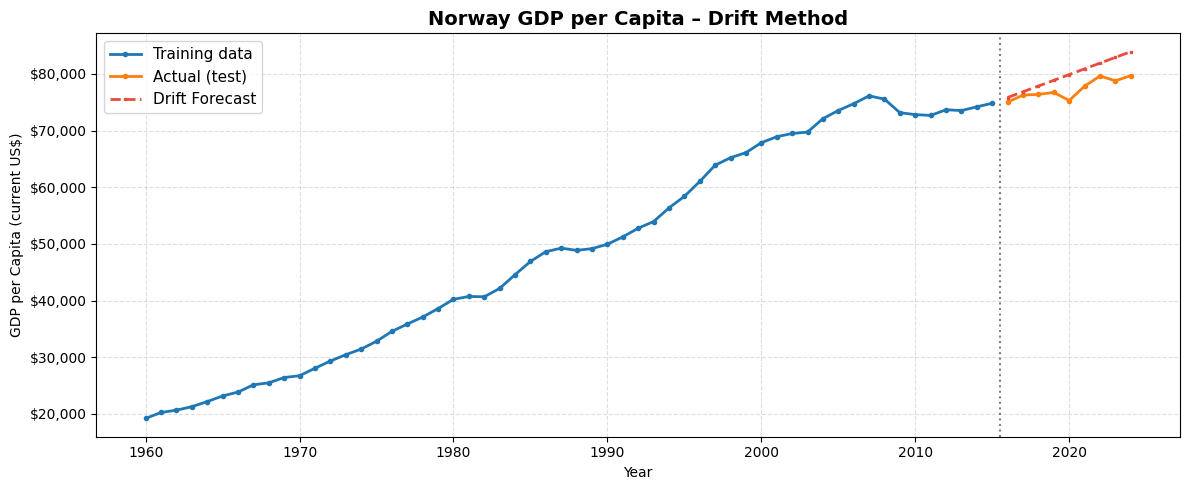


── Drift Forecast vs Actual ──
    Year  GDP_per_capita  drift_forecast
56  2016        75017.49        75820.88
57  2017        76247.41        76831.80
58  2018        76373.65        77842.72
59  2019        76712.29        78853.64
60  2020        75287.21        79864.56
61  2021        77812.71        80875.48
62  2022        79620.16        81886.40
63  2023        78775.75        82897.32
64  2024        79667.53        83908.24


In [21]:

slope = (y_train[-1] - y_train[0]) / (len(y_train) - 1)
drift_forecast = np.array([y_train[-1] + slope * h for h in range(1, len(y_test) + 1)])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_train, y_train,        color="#1f77b4", linewidth=2, marker="o", markersize=3, label="Training data")
ax.plot(years_test,  y_test,         color="#ff7f0e", linewidth=2, marker="o", markersize=3, label="Actual (test)")
ax.plot(years_test,  drift_forecast, color="#e74c3c", linewidth=2, linestyle="--", marker="s", markersize=2, label="Drift Forecast")
ax.axvline(x=years_test[0] - 0.5, color="gray", linestyle=":", linewidth=1.5)
ax.set_title("Norway GDP per Capita – Drift Method", fontsize=14, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("GDP per Capita (current US$)")
ax.yaxis.set_major_formatter(fmt); ax.legend(fontsize=11); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.savefig("task3_drift.png", dpi=150); plt.show()



drift_forecast = pd.Series(drift_forecast, index=test.index)
test["drift_forecast"] = drift_forecast

comparison_drift = test[["Year", "GDP_per_capita", "drift_forecast"]].round(2)

print("\n── Drift Forecast vs Actual ──")
print(comparison_drift)

# ─────────────────────────────────────────────────────────────
* ### EXPONENTIAL SMOOTHING (HOLT'S LINEAR METHOD)
# ─────────────────────────────────────────────────────────────


── ETS Params ──
  Alpha (level)  : 1.0000
  Beta  (trend)  : 0.8845
  Phi   (damping): 0.8368


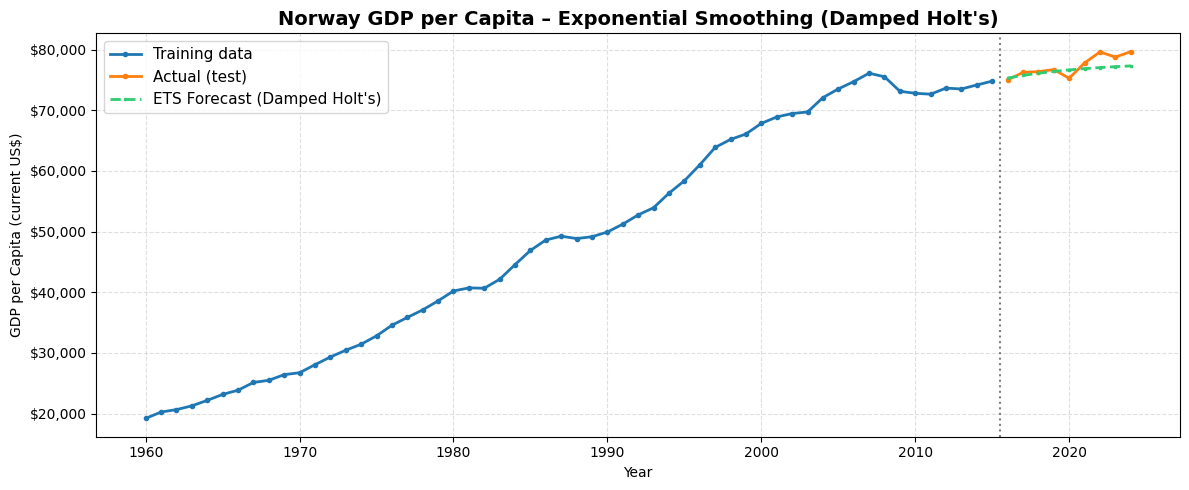


── ETS Forecast vs Actual ──
    Year  GDP_per_capita  ets_forecast
56  2016        75017.49      75323.16
57  2017        76247.41      75752.60
58  2018        76373.65      76111.95
59  2019        76712.29      76412.65
60  2020        75287.21      76664.27
61  2021        77812.71      76874.83
62  2022        79620.16      77051.02
63  2023        78775.75      77198.45
64  2024        79667.53      77321.82


In [22]:

ets_model    = ExponentialSmoothing(y_train, trend="add", damped_trend=True, seasonal=None).fit()
ets_forecast = ets_model.forecast(len(y_test))

print(f"\n── ETS Params ──")
print(f"  Alpha (level)  : {ets_model.params['smoothing_level']:.4f}")
print(f"  Beta  (trend)  : {ets_model.params['smoothing_trend']:.4f}")
print(f"  Phi   (damping): {ets_model.params['damping_trend']:.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_train, y_train,      color="#1f77b4", linewidth=2, marker="o", markersize=3, label="Training data")
ax.plot(years_test,  y_test,       color="#ff7f0e", linewidth=2, marker="o", markersize=3, label="Actual (test)")
ax.plot(years_test,  ets_forecast, color="#2ecc71", linewidth=2, linestyle="--", marker="s", markersize=2, label="ETS Forecast (Damped Holt's)")
ax.axvline(x=years_test[0] - 0.5, color="gray", linestyle=":", linewidth=1.5)
ax.set_title("Norway GDP per Capita – Exponential Smoothing (Damped Holt's)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("GDP per Capita (current US$)")
ax.yaxis.set_major_formatter(fmt); ax.legend(fontsize=11); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.savefig("task3_ets.png", dpi=150); plt.show()


ets_forecast = pd.Series(ets_forecast, index=test.index)
test["ets_forecast"] = ets_forecast

comparison_ets = test[["Year", "GDP_per_capita", "ets_forecast"]].round(2)

print("\n── ETS Forecast vs Actual ──")
print(comparison_ets)

# ─────────────────────────────────────────────────────────────
### ARIMA (On Box-Cox Transformed and differenced data)
# ─────────────────────────────────────────────────────────────


── ARIMA(1,1,1) ──
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   56
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -252.978
Date:                Mon, 13 Apr 2026   AIC                            511.956
Time:                        19:31:10   BIC                            517.978
Sample:                             0   HQIC                           514.285
                                 - 56                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8561      0.092      9.280      0.000       0.675       1.037
ma.L1         -0.1342      0.138     -0.975      0.330      -0.404       0.136
sigma2       568.3853    116.641

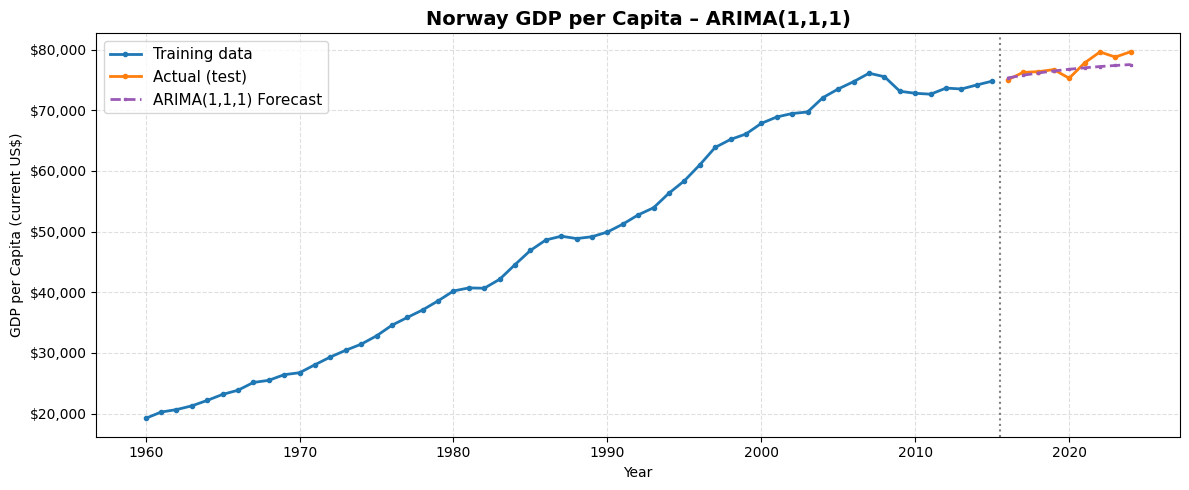


── ARIMA Forecast vs Actual ──
    Year  GDP_per_capita  arima_forecast
56  2016        75017.49        75330.11
57  2017        76247.41        75776.31
58  2018        76373.65        76158.96
59  2019        76712.29        76487.03
60  2020        75287.21        76768.24
61  2021        77812.71        77009.23
62  2022        79620.16        77215.73
63  2023        78775.75        77392.64
64  2024        79667.53        77544.20


In [23]:
from scipy.special import inv_boxcox

p, q = 1, 1    # from ACF/PACF reading above
arima_model    = ARIMA(y_model, order=(p, d, q)).fit()
arima_fc_trans = arima_model.forecast(len(y_test))
arima_forecast = inv_boxcox(arima_fc_trans, lam)   # back to US$

print(f"\n── ARIMA({p},{d},{q}) ──")
print(arima_model.summary())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years_train, y_train,        color="#1f77b4", linewidth=2, marker="o", markersize=3, label="Training data")
ax.plot(years_test,  y_test,         color="#ff7f0e", linewidth=2, marker="o", markersize=3, label="Actual (test)")
ax.plot(years_test,  arima_forecast, color="#9b59b6", linewidth=2, linestyle="--", marker="s", markersize=2, label=f"ARIMA({p},{d},{q}) Forecast")
ax.axvline(x=years_test[0] - 0.5, color="gray", linestyle=":", linewidth=1.5)
ax.set_title(f"Norway GDP per Capita – ARIMA({p},{d},{q})", fontsize=14, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("GDP per Capita (current US$)")
ax.yaxis.set_major_formatter(fmt); ax.legend(fontsize=11); ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout(); plt.savefig("task3_arima.png", dpi=150); plt.show()

arima_forecast = pd.Series(arima_forecast, index=test.index)
test["arima_forecast"] = arima_forecast

comparison_arima = test[["Year", "GDP_per_capita", "arima_forecast"]].round(2)

print("\n── ARIMA Forecast vs Actual ──")
print(comparison_arima)

# ─────────────────────────────────────────────────────────────
### Ljung-Box Test

# ─────────────────────────────────────────────────────────────

In [24]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(arima_model.resid, lags=[10], return_df=True)
print(lb_test)

     lb_stat  lb_pvalue
10  0.181899        1.0


# ─────────────────────────────────────────────────────────────
### STL DECOMPOSITION BASED FORECASTING
# ─────────────────────────────────────────────────────────────

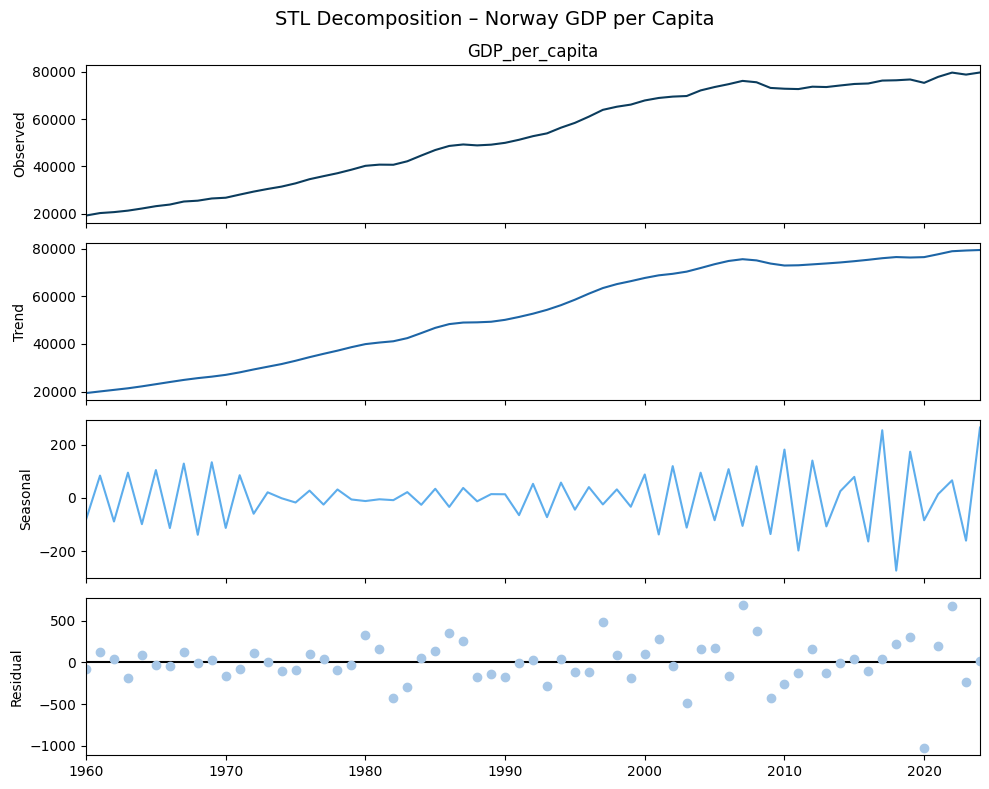


--- STL Forecast Accuracy ---
STL -> MAE: 672.16, RMSE: 956.86


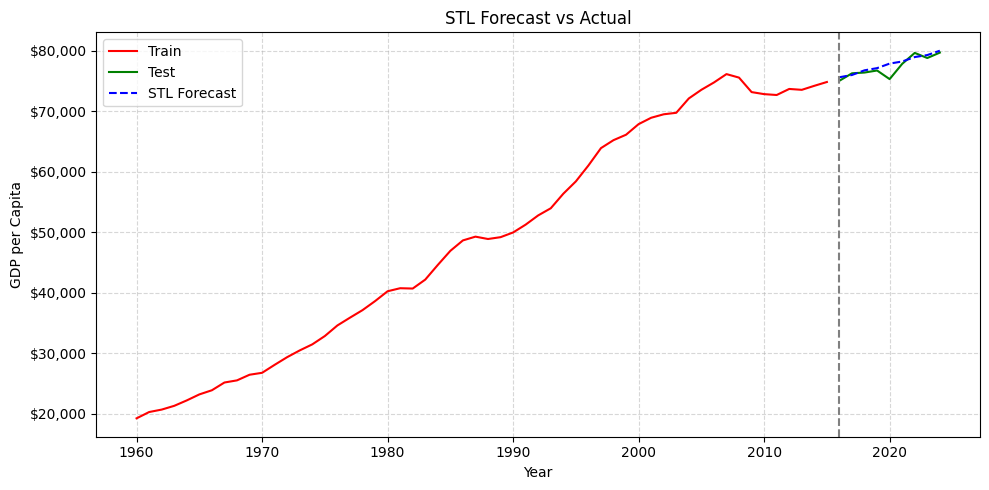

    Year  GDP_per_capita  stl_forecast
56  2016    75017.494477  75595.708355
57  2017    76247.411645  75973.057967
58  2018    76373.647461  76741.640918
59  2019    76712.287116  77102.084094
60  2020    75287.205953  77854.010038
61  2021    77812.711561  78198.041954
62  2022    79620.163546  78933.798760
63  2023    78775.749515  79261.900089
64  2024    79667.527231  79981.961339


In [25]:

y_train = train.set_index("Year")["GDP_per_capita"]
y_test  = test.set_index("Year")["GDP_per_capita"]

y_train.index = pd.to_datetime(y_train.index, format='%Y')
y_train = y_train.asfreq('YS')

y_test.index = pd.to_datetime(y_test.index, format='%Y')
y_test = y_test.asfreq('YS')


y_full = df.set_index("Year")["GDP_per_capita"]
y_full.index = pd.to_datetime(y_full.index, format='%Y')
y_full = y_full.asfreq('YS')

stl = STL(y_full, period=2)
res = stl.fit()

fig = res.plot()
axes = fig.get_axes()


axes[0].set_ylabel("Observed")
axes[1].set_ylabel("Trend")
axes[2].set_ylabel("Seasonal")
axes[3].set_ylabel("Residual")


axes[0].lines[0].set_color("#0B3C5D")
axes[1].lines[0].set_color("#1D65A6")
axes[2].lines[0].set_color("#5DADEC")
axes[3].lines[0].set_color("#A7C7E7")

fig.set_size_inches(10, 8)
plt.suptitle("STL Decomposition – Norway GDP per Capita", fontsize=14)
plt.tight_layout()
plt.show()

stlf = STLForecast(y_train, ARIMA, model_kwargs={"order": (1,1,1)}, period=2)
res_stlf = stlf.fit()

stl_forecast = res_stlf.forecast(steps=len(y_test))
stl_forecast.index = y_test.index

test["stl_forecast"] = stl_forecast.values


mae_stl = mean_absolute_error(test["GDP_per_capita"], test["stl_forecast"])
rmse_stl = np.sqrt(mean_squared_error(test["GDP_per_capita"], test["stl_forecast"]))

print("\n--- STL Forecast Accuracy ---")
print(f"STL -> MAE: {mae_stl:.2f}, RMSE: {rmse_stl:.2f}")


fig, ax = plt.subplots(figsize=(10,5))

ax.plot(y_train.index, y_train, color="red", label="Train")
ax.plot(y_test.index, y_test, color="green", label="Test")
ax.plot(stl_forecast.index, stl_forecast, linestyle="--", color="blue", label="STL Forecast")

ax.axvline(x=y_test.index[0], color="gray", linestyle="--")

ax.set_title("STL Forecast vs Actual")
ax.set_xlabel("Year")
ax.set_ylabel("GDP per Capita")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()


comparison = test[["Year", "GDP_per_capita", "stl_forecast"]]
print(comparison)

# ─────────────────────────────────────────────────────────────
### STEP 4: MODEL EVALUATION 
# ─────────────────────────────────────────────────────────────

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_excel("Dataset.xlsx")

df.columns = ["Year", "Country", "GDP_per_capita"]
df = df.sort_values("Year").reset_index(drop=True)

TEST_SIZE = 9
train = df.iloc[:-TEST_SIZE].copy()
test  = df.iloc[-TEST_SIZE:].copy()

y_train     = train["GDP_per_capita"].values
y_test      = test["GDP_per_capita"].values
years_train = train["Year"].values
years_test  = test["Year"].values

fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")



def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100



mean_value = train["GDP_per_capita"].mean()
test["mean_forecast"] = mean_value



last_value = train["GDP_per_capita"].iloc[-1]
test["naive_forecast"] = last_value



slope = (y_train[-1] - y_train[0]) / (len(y_train) - 1)
drift_forecast = np.array([y_train[-1] + slope * h for h in range(1, len(y_test) + 1)])
test["drift_forecast"] = drift_forecast



ets_model = ExponentialSmoothing(y_train, trend="add", damped_trend=True).fit()
ets_forecast = ets_model.forecast(len(y_test))
test["ets_forecast"] = ets_forecast


arima_model = ARIMA(y_train, order=(1,1,1)).fit()
arima_forecast = arima_model.forecast(len(y_test))
test["arima_forecast"] = arima_forecast



print("\n── Mean Forecast ──")
print(test[["Year", "GDP_per_capita", "mean_forecast"]].round(2))

print("\n── Naive Forecast ──")
print(test[["Year", "GDP_per_capita", "naive_forecast"]].round(2))

print("\n── Drift Forecast ──")
print(test[["Year", "GDP_per_capita", "drift_forecast"]].round(2))

print("\n── ETS Forecast ──")
print(test[["Year", "GDP_per_capita", "ets_forecast"]].round(2))

print("\n── ARIMA Forecast ──")
print(test[["Year", "GDP_per_capita", "arima_forecast"]].round(2))




mae_mean  = mean_absolute_error(y_test, test["mean_forecast"])
rmse_mean = np.sqrt(mean_squared_error(y_test, test["mean_forecast"]))
mape_mean = mape(y_test, test["mean_forecast"])

mae_naive  = mean_absolute_error(y_test, test["naive_forecast"])
rmse_naive = np.sqrt(mean_squared_error(y_test, test["naive_forecast"]))
mape_naive = mape(y_test, test["naive_forecast"])

mae_drift  = mean_absolute_error(y_test, test["drift_forecast"])
rmse_drift = np.sqrt(mean_squared_error(y_test, test["drift_forecast"]))
mape_drift = mape(y_test, test["drift_forecast"])

mae_ets  = mean_absolute_error(y_test, test["ets_forecast"])
rmse_ets = np.sqrt(mean_squared_error(y_test, test["ets_forecast"]))
mape_ets = mape(y_test, test["ets_forecast"])

mae_arima  = mean_absolute_error(y_test, test["arima_forecast"])
rmse_arima = np.sqrt(mean_squared_error(y_test, test["arima_forecast"]))
mape_arima = mape(y_test, test["arima_forecast"])



evaluation_table = pd.DataFrame({
    "Model": ["Mean", "Naive", "Drift", "ETS", "ARIMA"],
    "MAE":   [mae_mean, mae_naive, mae_drift, mae_ets, mae_arima],
    "RMSE":  [rmse_mean, rmse_naive, rmse_drift, rmse_ets, rmse_arima],
    "MAPE":  [mape_mean, mape_naive, mape_drift, mape_ets, mape_arima]
}).round(2)

print("\n── Final Model Comparison ──")
print(evaluation_table)


── Mean Forecast ──
    Year  GDP_per_capita  mean_forecast
56  2016        75017.49       49019.83
57  2017        76247.41       49019.83
58  2018        76373.65       49019.83
59  2019        76712.29       49019.83
60  2020        75287.21       49019.83
61  2021        77812.71       49019.83
62  2022        79620.16       49019.83
63  2023        78775.75       49019.83
64  2024        79667.53       49019.83

── Naive Forecast ──
    Year  GDP_per_capita  naive_forecast
56  2016        75017.49        74809.97
57  2017        76247.41        74809.97
58  2018        76373.65        74809.97
59  2019        76712.29        74809.97
60  2020        75287.21        74809.97
61  2021        77812.71        74809.97
62  2022        79620.16        74809.97
63  2023        78775.75        74809.97
64  2024        79667.53        74809.97

── Drift Forecast ──
    Year  GDP_per_capita  drift_forecast
56  2016        75017.49        75820.88
57  2017        76247.41        76831.80
58

   Year  ARIMA_Forecast
0  2025    80193.629419
1  2026    80712.586427
2  2027    81224.494346
3  2028    81729.448012
4  2029    82227.541020
5  2030    82718.865739
6  2031    83203.513329
7  2032    83681.573750
8  2033    84153.135783
9  2034    84618.287041


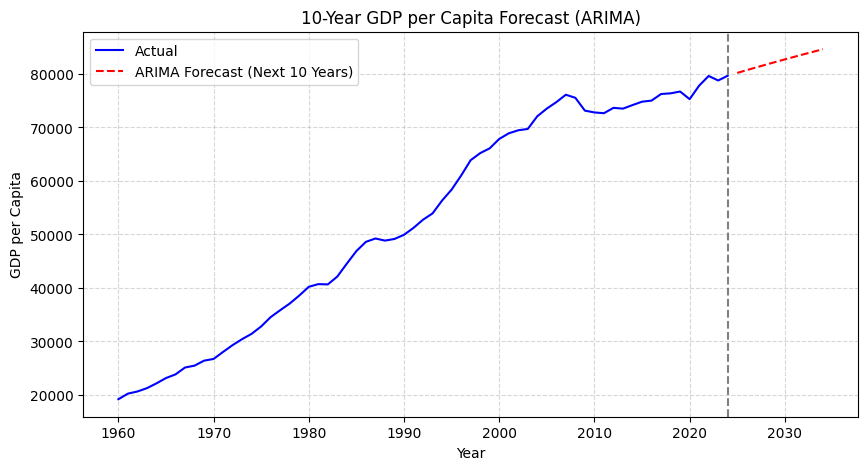

In [21]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import boxcox
from scipy.special import inv_boxcox


y_full, lam = boxcox(df["GDP_per_capita"])


p, d, q = 1, 1, 1   # your chosen order

arima_model_full = ARIMA(y_full, order=(p, d, q)).fit()


steps = 10
arima_future_trans = arima_model_full.forecast(steps=steps)


arima_future = inv_boxcox(arima_future_trans, lam)


last_year = df["Year"].iloc[-1]
future_years = np.arange(last_year + 1, last_year + steps + 1)

future_df = pd.DataFrame({
    "Year": future_years,
    "ARIMA_Forecast": arima_future
})

print(future_df)


fig, ax = plt.subplots(figsize=(10, 5))

# Actual data
ax.plot(df["Year"], df["GDP_per_capita"], label="Actual", color="blue")

# Forecast
ax.plot(future_df["Year"], future_df["ARIMA_Forecast"],
        linestyle="--", color="red",
        label="ARIMA Forecast (Next 10 Years)")

# Boundary line
ax.axvline(x=last_year, color="gray", linestyle="--")

ax.set_title("10-Year GDP per Capita Forecast (ARIMA)")
ax.set_xlabel("Year")
ax.set_ylabel("GDP per Capita")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.show()

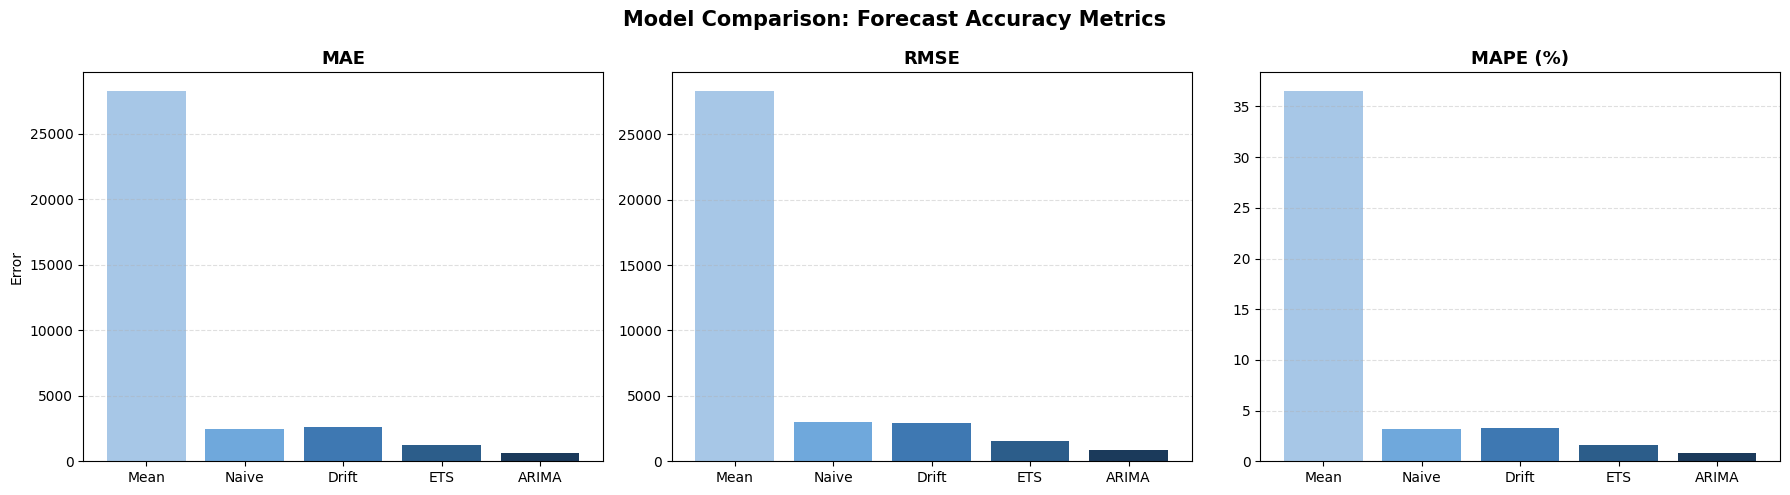

In [28]:
import matplotlib.pyplot as plt
import numpy as np


models = ["Mean", "Naive", "Drift", "ETS", "ARIMA"]
mae   = [28259.52, 2469.39, 2585.21, 1255.97, 610.22]
rmse  = [28308.63, 2979.17, 2947.13, 1565.44, 896.20]
mape  = [36.54, 3.15, 3.33, 1.60, 0.80]

colors = ["#A7C7E7", "#6FA8DC", "#3E78B2", "#2C5D8A", "#1B3A5B"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].bar(models, mae, color=colors)
axes[0].set_title("MAE", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Error")
axes[0].grid(axis='y', linestyle='--', alpha=0.4)


axes[1].bar(models, rmse, color=colors)
axes[1].set_title("RMSE", fontsize=13, fontweight="bold")
axes[1].grid(axis='y', linestyle='--', alpha=0.4)


axes[2].bar(models, mape, color=colors)
axes[2].set_title("MAPE (%)", fontsize=13, fontweight="bold")
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle("Model Comparison: Forecast Accuracy Metrics", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
### **10 Year Forecasting with Confidence Intervals**
# ─────────────────────────────────────────────────────────────

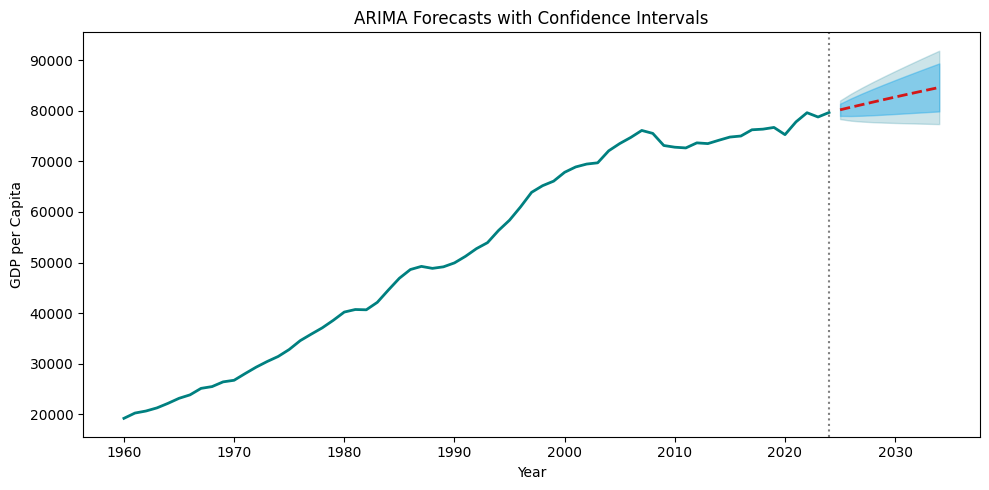

In [19]:
# Forecast object
forecast_obj = arima_model_full.get_forecast(steps=steps)

# Mean forecast
arima_future_trans = forecast_obj.predicted_mean

# Confidence intervals
conf_int_95 = forecast_obj.conf_int(alpha=0.05)
conf_int_80 = forecast_obj.conf_int(alpha=0.20)

# Inverse Box-Cox
arima_future = inv_boxcox(arima_future_trans, lam)

lower_95 = inv_boxcox(conf_int_95[:, 0], lam)
upper_95 = inv_boxcox(conf_int_95[:, 1], lam)

lower_80 = inv_boxcox(conf_int_80[:, 0], lam)
upper_80 = inv_boxcox(conf_int_80[:, 1], lam)

fig, ax = plt.subplots(figsize=(10, 5))

# Actual data
ax.plot(df["Year"], df["GDP_per_capita"], color="teal", linewidth=2)

# Forecast line (dots + line)
ax.plot(future_years, arima_future,
        color="#d41717", linewidth=2, linestyle='--')

# 95% CI (lighter outer band)
ax.fill_between(future_years, lower_95, upper_95,
                color="#047C94", alpha=0.2)

# 80% CI (darker inner band)
ax.fill_between(future_years, lower_80, upper_80,
                color="#19a7e9", alpha=0.4)

# Vertical split line
ax.axvline(x=df["Year"].iloc[-1],
           color="gray", linestyle=":", linewidth=1.5)

ax.set_title("ARIMA Forecasts with Confidence Intervals")
ax.set_xlabel("Year")
ax.set_ylabel("GDP per Capita")

plt.tight_layout()
plt.show()